## Dự báo chi tiêu – Transformer Phi-hồi quy (Non-Autoregressive)

**Kiến trúc tự xây dựng từ đầu** – không dùng pretrained model, không import model có sẵn:

```
ENCODER (chuỗi lịch sử – 30 bước)
  past input (amount + lịch + share) → Linear → + pos_enc
  → N_ENC_LAYERS × EncoderBlock (Multi-Head Self-Attention + FFN + LayerNorm)
  → memory: (B, 30, d_model)

DECODER (tương lai – 7 bước, PHI-HỒI QUY)
  future feats (lịch + share) → Linear → + pos_enc
  → N_DEC_LAYERS × DecoderBlock:
      ① Self-Attention (7 bước tương lai attend lẫn nhau)
      ② Cross-Attention (← memory: attend toàn bộ 30 bước lịch sử)
      ③ FFN + LayerNorm
  → Linear → 7 dự báo SONG SONG (không tích luỹ lỗi)
```

**Ưu điểm so với LSTM Seq2Seq cũ:**
- **Phi-hồi quy**: 7 bước sinh đồng thời → **không tích luỹ lỗi** từ bước trước
- **Global attention**: decoder thấy toàn bộ 30 ngày lịch sử, không chỉ hidden state cuối
- **GELU + Post-LayerNorm**: huấn luyện ổn định, phù hợp chuỗi ngắn

---

**Dataset `daily_spending_train.csv`:**
- **1,551 ngày** (2021-01-01 → 2025-03-31) – 5 kỳ Tết, pattern đa dạng
- Augment: 7 biến thể scale ±15% + nhiễu 2%  |  Val: 60 ngày cuối

**Đặc trưng lịch (8 kênh):** sin/cos_dow, weekend, sin/cos_month, sin/cos_dom, early_month_pulse  
**Huấn luyện:** Huber Loss · AdamW · CosineAnnealing · Early Stopping

In [1]:

import os, sys
from google.colab import drive          # type: ignore[import]
drive.mount("/content/drive", force_remount=False)

# ── Bước 2: Đặt đường dẫn (sửa nếu bạn để thư mục khác) ─────────────────────
AI_SERVICE_ROOT = "/content/drive/MyDrive/thesis/ai_service"

# ── Bước 3: Thêm vào sys.path và chuyển thư mục làm việc ─────────────────────
if AI_SERVICE_ROOT not in sys.path:
    sys.path.insert(0, AI_SERVICE_ROOT)
os.chdir(AI_SERVICE_ROOT)

import torch
print(f"✅ Working dir  : {os.getcwd()}")
print(f"✅ GPU available: {torch.cuda.is_available()}")
print(f"✅ GPU name      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print("━" * 45)
print("  Bây giờ hãy chạy các cell tiếp theo bình thường")


Mounted at /content/drive
✅ Working dir  : /content/drive/MyDrive/thesis/ai_service
✅ GPU available: True
✅ GPU name      : Tesla T4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bây giờ hãy chạy các cell tiếp theo bình thường


In [2]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# ── Paths ───────────────────────────────────────────────────────────────────
def _ai_service_root() -> Path:
    here = Path.cwd().resolve()
    for r in (here, here / "ai_service", here.parent / "ai_service"):
        if (r / "app" / "forecast_net.py").is_file():
            return r
    raise RuntimeError("Không tìm thấy app/forecast_net.py – chạy notebook từ thư mục ai_service/")


ROOT = _ai_service_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA   = ROOT / "data" / "daily_spending_train.csv"
MODELS = ROOT / "models"
MODELS.mkdir(parents=True, exist_ok=True)

# Buộc reload module để kernel luôn dùng phiên bản mới nhất của file
import app.forecast_features as _ff_mod
import app.forecast_net as _fn_mod
import app.forecast_infer as _fi_mod
importlib.reload(_ff_mod)
importlib.reload(_fn_mod)
importlib.reload(_fi_mod)

from app.forecast_features import (
    N_CALENDAR,
    N_CATEGORY,
    N_TIME_AND_CAT,
    calendar_feats_numpy,
    category_shares_from_df,
    decoder_time_feats_from_arrays,
    stack_encoder_feats,
)
from app.forecast_net import SpendingForecastTransformer

# ── Hyperparameters ─────────────────────────────────────────────────────────
WINDOW       = 30          # encoder window (ngày)
HORIZON      = 7           # forecast horizon (ngày)
INPUT_SIZE   = 1 + N_TIME_AND_CAT  # 1 amount + 8 lịch + 5 category = 14
# Transformer hyperparameters
D_MODEL      = 64          # chiều ẩn (d_model), phải chia hết cho N_HEADS
N_HEADS      = 4           # số đầu attention (multi-head)
N_ENC_LAYERS = 3           # số lớp Encoder
N_DEC_LAYERS = 2           # số lớp Decoder
D_FF         = 256         # chiều FFN (4 × D_MODEL)
DROPOUT      = 0.10
LR           = 3e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 32
EPOCHS           = 300
PATIENCE         = 40      # early stopping patience
N_AUG            = 7       # số biến thể augmentation
VAL_DAYS         = 60      # số ngày cuối dùng làm val (~8 tuần, bao gồm cả cuối tuần)
# Ngày chi tiêu < MIN_VALID_VND bị coi là bất thường (thiếu data, lỗi nhập liệu...)
# Dataset mới đã có minimum 66,974 VND nên threshold này chỉ là safety net
MIN_VALID_VND    = 50_000.0
# Instance Norm chỉ tính mu/sig từ K ngày GẦN NHẤT trong window
# → neo vào mức chi tiêu hiện tại, không bị kéo bởi giai đoạn thấp xa trong quá khứ
INST_NORM_K      = 14

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {DEVICE}")
print(f"Input size  : {INPUT_SIZE}  (1 amount + {N_CALENDAR} calendar + {N_CATEGORY} category)")
print(f"Window/Horizon: {WINDOW}/{HORIZON}")

Device      : cuda
Input size  : 14  (1 amount + 8 calendar + 5 category)
Window/Horizon: 30/7


Dữ liệu gốc: 1551 ngày  (2021-01-01 → 2025-03-31)
Không có giá trị bất thường cần nội suy
mean_log = 12.3033  |  std_log = 0.3610  |  median_log = 12.2926
Tương đương VND: mean ~ 220,412  |  median ~ 218,075


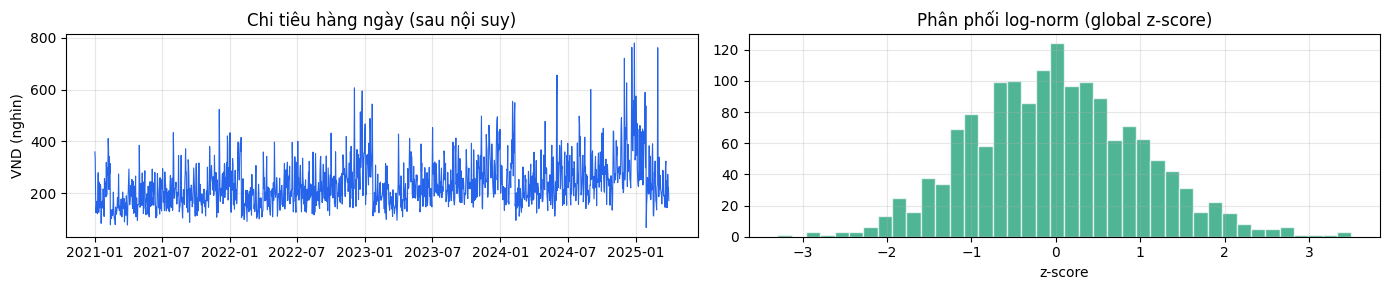

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. Tải và làm sạch dữ liệu
# ══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv(DATA, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"Dữ liệu gốc: {len(df)} ngày  ({df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()})")

series_raw = df["total_expense_vnd"].values.astype(np.float64)

# ── Nội suy tuyến tính giá trị quá thấp ────────────────────────────────────
# Các giá trị < MIN_VALID_VND thường là ngày thiếu dữ liệu thực, không phản ánh
# mức chi tiêu thật → thay bằng nội suy để không méo phân phối khi huấn luyện.
mask_low = series_raw < MIN_VALID_VND
if mask_low.any():
    idx = np.arange(len(series_raw))
    ok_idx  = idx[~mask_low]
    bad_idx = idx[mask_low]
    series_raw[mask_low] = np.interp(bad_idx, ok_idx, series_raw[ok_idx])
    series_raw = np.maximum(series_raw, MIN_VALID_VND)
    print(f"Đã nội suy {mask_low.sum()} ngày có giá trị < {MIN_VALID_VND:,.0f} VND")
else:
    print("Không có giá trị bất thường cần nội suy")

# ── Normalization stats ─────────────────────────────────────────────────────
# Tính từ chuỗi đã làm sạch → mean_log / std_log dùng cho global z-score
log_raw    = np.log1p(series_raw)
mean_log   = float(log_raw.mean())
median_log = float(np.median(log_raw))
std_log    = float(max(log_raw.std(), 1e-6))
eps        = 1e-8
log_norm   = (log_raw - mean_log) / (std_log + eps)   # global z-score

print(f"mean_log = {mean_log:.4f}  |  std_log = {std_log:.4f}  |  median_log = {median_log:.4f}")
print(f"Tương đương VND: mean ~ {np.expm1(mean_log):,.0f}  |  median ~ {np.expm1(median_log):,.0f}")

# ── Category shares ─────────────────────────────────────────────────────────
shares         = category_shares_from_df(df)
mean_category  = shares.mean(axis=0)
mean_category /= max(float(mean_category.sum()), 1e-9)

# ── Calendar features ────────────────────────────────────────────────────────
dates_all = df["date"].values.astype("datetime64[D]")
cal_all   = calendar_feats_numpy(dates_all)   # (T, 7)

# ── Visualize ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].plot(df["date"], series_raw / 1000, linewidth=0.8, color="#2563eb")
axes[0].set_title("Chi tiêu hàng ngày (sau nội suy)")
axes[0].set_ylabel("VND (nghìn)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(log_norm, bins=40, color="#059669", alpha=0.7, edgecolor="white")
axes[1].set_title("Phân phối log-norm (global z-score)")
axes[1].set_xlabel("z-score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. Xây dựng dataset (sliding window + augmentation)
# ══════════════════════════════════════════════════════════════════════════════

def make_windows(
    lognorm_arr: np.ndarray,   # (T,) global z-score
    cal_arr: np.ndarray,       # (T, N_CALENDAR)
    shares_arr: np.ndarray,    # (T, N_CATEGORY)
    window: int,
    horizon: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Sliding window → (X, Y, dec_feats).

    X        : (n, W, INPUT_SIZE)   – encoder input
    Y        : (n, H)               – targets global z-score
    dec_feats: (n, H, N_TIME_AND_CAT) – decoder time feats
    """
    T = len(lognorm_arr)
    n = T - window - horizon + 1
    if n < 1:
        raise ValueError(f"Chuỗi quá ngắn ({T}) cho window={window}, horizon={horizon}")

    X_list, Y_list, Dec_list = [], [], []
    for i in range(n):
        # Encoder
        x_amt = lognorm_arr[i : i + window]            # (W,)
        x_cal = cal_arr[i : i + window]                # (W, 7)
        x_sha = shares_arr[i : i + window]             # (W, 5)
        X = np.concatenate(
            [x_amt.reshape(-1, 1), x_cal, x_sha], axis=1
        ).astype(np.float32)                           # (W, 13)

        # Targets
        y_amt = lognorm_arr[i + window : i + window + horizon].astype(np.float32)  # (H,)

        # Decoder time features
        d_cal = cal_arr[i + window : i + window + horizon]    # (H, 7)
        d_sha = shares_arr[i + window : i + window + horizon] # (H, 5)
        dec   = np.concatenate([d_cal, d_sha], axis=1).astype(np.float32)  # (H, 12)

        X_list.append(X)
        Y_list.append(y_amt)
        Dec_list.append(dec)

    return (
        np.array(X_list,   dtype=np.float32),
        np.array(Y_list,   dtype=np.float32),
        np.array(Dec_list, dtype=np.float32),
    )


def augment_series(
    raw: np.ndarray,
    rng: np.random.Generator,
    n_aug: int,
) -> list[np.ndarray]:
    """Tạo n_aug biến thể global-z-score bằng scale ±15% + nhiễu 2%."""
    T    = len(raw)
    result = []
    for _ in range(n_aug):
        scale = rng.uniform(0.85, 1.15)
        noise = rng.normal(0.0, raw.mean() * 0.02, T)
        aug   = np.maximum(raw * scale + noise, 1.0)
        aug_log  = np.log1p(aug)
        aug_norm = (aug_log - mean_log) / (std_log + eps)
        result.append(aug_norm.astype(np.float32))
    return result


rng = np.random.default_rng(42)

# Windows từ chuỗi gốc
X_base, Y_base, Dec_base = make_windows(log_norm, cal_all, shares, WINDOW, HORIZON)
print(f"Base windows : {len(X_base)}")

# Augmentation
aug_norms = augment_series(series_raw, rng, N_AUG)
X_aug_list,   Y_aug_list,   Dec_aug_list   = [X_base],   [Y_base],   [Dec_base]
for aln in aug_norms:
    Xa, Ya, Da = make_windows(aln, cal_all, shares, WINDOW, HORIZON)
    X_aug_list.append(Xa)
    Y_aug_list.append(Ya)
    Dec_aug_list.append(Da)

# ── Train / Val split ────────────────────────────────────────────────────────
# Val: n_val cửa sổ cuối của chuỗi gốc (không dùng aug)
n_val = max(1, VAL_DAYS - HORIZON + 1)
X_val,   Y_val,   Dec_val   = X_base[-n_val:],   Y_base[-n_val:],   Dec_base[-n_val:]

# Train: phần còn lại của base + toàn bộ aug
n_base_train = max(0, len(X_base) - n_val)
X_train_parts  = [X_base[:n_base_train]]
Y_train_parts  = [Y_base[:n_base_train]]
Dec_train_parts = [Dec_base[:n_base_train]]
for Xa, Ya, Da in zip(X_aug_list[1:], Y_aug_list[1:], Dec_aug_list[1:]):
    X_train_parts.append(Xa)
    Y_train_parts.append(Ya)
    Dec_train_parts.append(Da)

X_train   = np.concatenate(X_train_parts,   axis=0)
Y_train   = np.concatenate(Y_train_parts,   axis=0)
Dec_train = np.concatenate(Dec_train_parts, axis=0)

print(f"Train        : {len(X_train)}  |  Val: {len(X_val)}")
print(f"X shape      : {X_train.shape}  (n, window={WINDOW}, features={INPUT_SIZE})")

# ── DataLoaders ──────────────────────────────────────────────────────────────
ds_train = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(Y_train),
    torch.from_numpy(Dec_train),
)
ds_val = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(Y_val),
    torch.from_numpy(Dec_val),
)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)

Base windows : 1515
Train        : 12066  |  Val: 54
X shape      : (12066, 30, 14)  (n, window=30, features=14)


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. Khởi tạo model + vòng lặp huấn luyện
# ══════════════════════════════════════════════════════════════════════════════

model = SpendingForecastTransformer(
    window=WINDOW,
    horizon=HORIZON,
    input_size=INPUT_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_enc_layers=N_ENC_LAYERS,
    n_dec_layers=N_DEC_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    use_instance_norm=True,
    inst_norm_recent_k=INST_NORM_K,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tham số huấn luyện: {n_params:,}")
print(model)

opt    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR * 0.05)
loss_fn = nn.HuberLoss(delta=1.0)

# ── Training loop ─────────────────────────────────────────────────────────────
history    = {"train": [], "val": [], "val_mape": [], "lr": []}
best_val   = float("inf")
best_state : dict | None = None
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    # SpendingForecastTransformer là phi-hồi quy — không dùng teacher forcing
    tf_ratio = 0.0

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for bx, by, bdec in dl_train:
        bx, by, bdec = bx.to(DEVICE), by.to(DEVICE), bdec.to(DEVICE)
        opt.zero_grad()
        pred = model(bx, decoder_time_feats=bdec)
        loss = loss_fn(pred, by)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        train_loss += loss.item() * len(bx)
    train_loss /= len(ds_train)

    # ── Validation ───────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    _pv_ep, _tv_ep = [], []
    with torch.no_grad():
        for bx, by, bdec in dl_val:
            bx, by, bdec = bx.to(DEVICE), by.to(DEVICE), bdec.to(DEVICE)
            pred = model(bx, decoder_time_feats=bdec)
            val_loss += loss_fn(pred, by).item() * len(bx)
            _pv_ep.append(pred.cpu().numpy())
            _tv_ep.append(by.cpu().numpy())
    val_loss /= max(len(ds_val), 1)

    # Tính Val MAPE để vẽ accuracy curve
    _pv_n = np.concatenate(_pv_ep)
    _tv_n = np.concatenate(_tv_ep)
    _pv_v = np.expm1(np.clip(_pv_n * (std_log + eps) + mean_log, 0.0, 25.0))
    _tv_v = np.expm1(np.clip(_tv_n * (std_log + eps) + mean_log, 0.0, 25.0))
    ep_mape = float(np.mean(np.abs(_pv_v - _tv_v) / (_tv_v + 1.0)) * 100)

    sched.step()
    cur_lr = sched.get_last_lr()[0]

    history["train"].append(train_loss)
    history["val"].append(val_loss)
    history["val_mape"].append(ep_mape)
    history["lr"].append(cur_lr)

    # Early stopping
    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{EPOCHS} | "
            f"TL={train_loss:.4f} | VL={val_loss:.4f} | "
            f"VMAPE={ep_mape:.2f}% | LR={cur_lr:.2e}"
        )

    if no_improve >= PATIENCE:
        print(f"Early stopping tại epoch {epoch}  (best val={best_val:.4f})")
        break

# Khôi phục checkpoint tốt nhất
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)
print(f"\nBest val loss: {best_val:.4f}")

Tham số huấn luyện: 286,657
SpendingForecastTransformer(
  (enc_proj): Linear(in_features=14, out_features=64, bias=True)
  (enc_blocks): ModuleList(
    (0-2): 3 x _EncoderBlock(
      (attn): _MultiHeadSelfAttn(
        (W_qkv): Linear(in_features=64, out_features=192, bias=False)
        (W_out): Linear(in_features=64, out_features=64, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
      (ff): _FFN(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=64, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (enc_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dec_pro

Val MAE  :        4,692 VND
Val RMSE :        8,126 VND
Val MAPE :        1.76 %


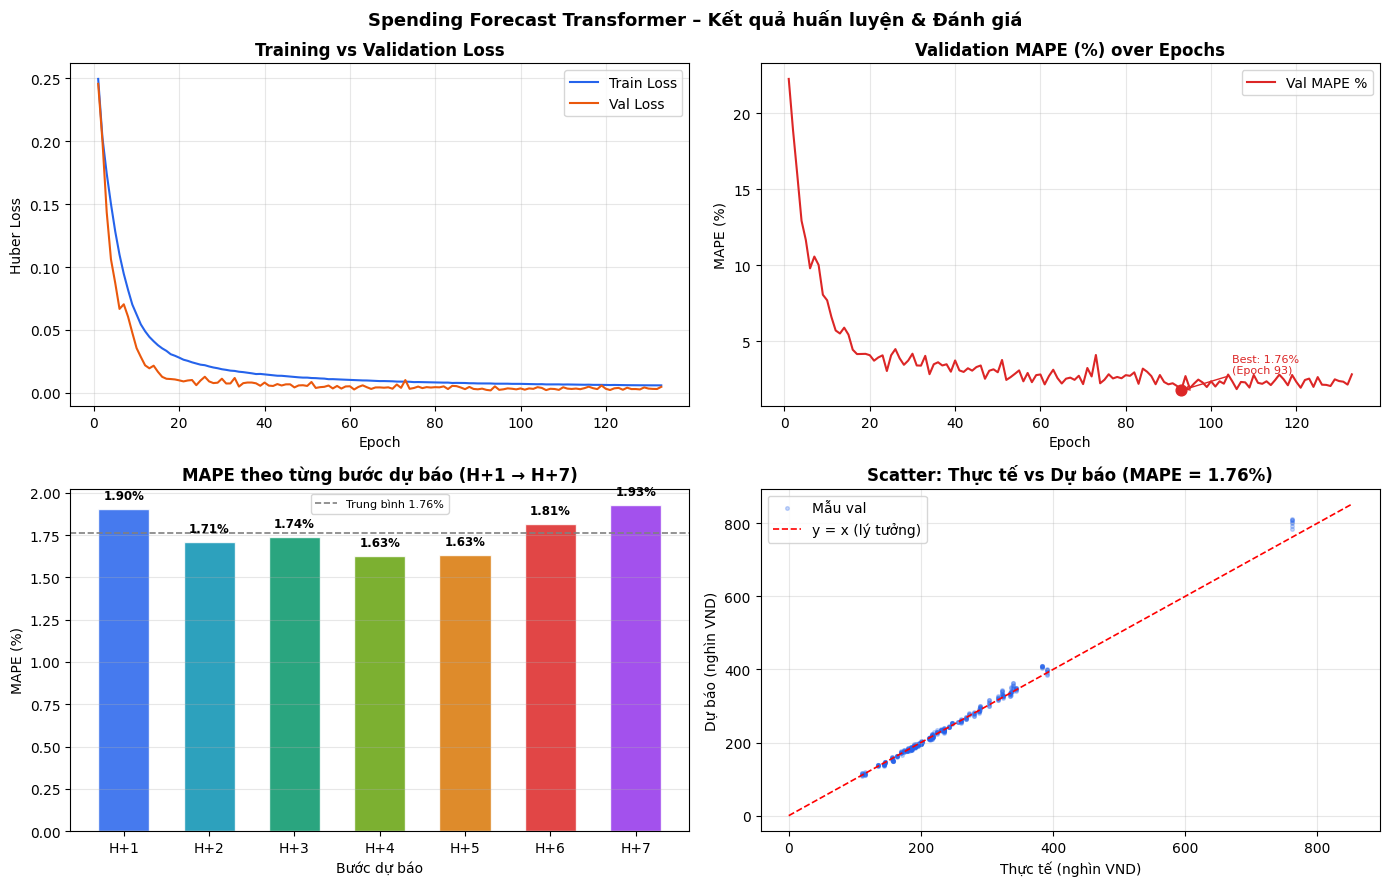

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. Đánh giá và visualize
# ══════════════════════════════════════════════════════════════════════════════

def denorm_vnd(z: np.ndarray) -> np.ndarray:
    """Global z-score → VND."""
    lg = z * (std_log + eps) + mean_log
    return np.expm1(np.clip(lg, 0.0, 25.0))


model.eval()
preds_list, targets_list = [], []
with torch.no_grad():
    for bx, by, bdec in dl_val:
        bx, by, bdec = bx.to(DEVICE), by.to(DEVICE), bdec.to(DEVICE)
        preds_list.append(model(bx, decoder_time_feats=bdec).cpu().numpy())
        targets_list.append(by.cpu().numpy())

preds_val   = np.concatenate(preds_list,   axis=0)   # (n_val, H)
targets_val = np.concatenate(targets_list, axis=0)   # (n_val, H)

pred_vnd = denorm_vnd(preds_val)
tgt_vnd  = denorm_vnd(targets_val)

mae_vnd = np.mean(np.abs(pred_vnd - tgt_vnd))
mape    = np.mean(np.abs(pred_vnd - tgt_vnd) / (tgt_vnd + 1.0)) * 100.0
rmse    = np.sqrt(np.mean((pred_vnd - tgt_vnd) ** 2))
print(f"Val MAE  : {mae_vnd:>12,.0f} VND")
print(f"Val RMSE : {rmse:>12,.0f} VND")
print(f"Val MAPE : {mape:>11.2f} %")

# ══════════════════════════════════════════════════════════════════════════════
# Biểu đồ đánh giá (4 charts — chuẩn luận văn)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Spending Forecast Transformer – Kết quả huấn luyện & Đánh giá",
             fontsize=13, fontweight="bold")

epochs_x = np.arange(1, len(history["train"]) + 1)

# ── [0,0] Training vs Validation Loss ────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs_x, history["train"], label="Train Loss", color="#2563eb", linewidth=1.5)
ax.plot(epochs_x, history["val"],   label="Val Loss",   color="#ea580c", linewidth=1.5)
ax.set_title("Training vs Validation Loss", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── [0,1] Validation MAPE % theo epoch ───────────────────────────────────────
ax = axes[0, 1]
val_mape_hist = history.get("val_mape", [])
if val_mape_hist:
    ax.plot(epochs_x[:len(val_mape_hist)], val_mape_hist,
            label="Val MAPE %", color="#dc2626", linewidth=1.5)
    best_ep = int(np.argmin(val_mape_hist))
    ax.scatter([best_ep + 1], [val_mape_hist[best_ep]],
               color="#dc2626", s=60, zorder=5)
    ax.annotate(f"Best: {val_mape_hist[best_ep]:.2f}%\n(Epoch {best_ep+1})",
                xy=(best_ep + 1, val_mape_hist[best_ep]),
                xytext=(best_ep + max(3, len(val_mape_hist)//10),
                        val_mape_hist[best_ep] + max(val_mape_hist)*0.05),
                fontsize=8, color="#dc2626",
                arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1))
else:
    ax.text(0.5, 0.5, "Cần train lại để có MAPE curve",
            ha="center", va="center", transform=ax.transAxes, color="gray")
ax.set_title("Validation MAPE (%) over Epochs", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAPE (%)")
ax.legend()
ax.grid(True, alpha=0.3)

# ── [1,0] MAPE theo từng bước dự báo H+1 → H+7 ─────────────────────────────
ax = axes[1, 0]
step_mapes_v = [
    float(np.mean(np.abs(pred_vnd[:, h] - tgt_vnd[:, h]) / (tgt_vnd[:, h] + 1.0)) * 100)
    for h in range(HORIZON)
]
steps   = np.arange(1, HORIZON + 1)
colors7 = ["#2563eb","#0891b2","#059669","#65a30d","#d97706","#dc2626","#9333ea"]
bars = ax.bar(steps, step_mapes_v, color=colors7, alpha=0.85, width=0.6, edgecolor="white")
ax.axhline(mape, color="gray", linestyle="--", linewidth=1.2,
           label=f"Trung bình {mape:.2f}%")
for bar, m in zip(bars, step_mapes_v):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f"{m:.2f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax.set_title("MAPE theo từng bước dự báo (H+1 → H+7)", fontweight="bold")
ax.set_xlabel("Bước dự báo")
ax.set_ylabel("MAPE (%)")
ax.set_xticks(steps)
ax.set_xticklabels([f"H+{h}" for h in steps])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# ── [1,1] Scatter: Thực tế vs Dự báo ────────────────────────────────────────
ax = axes[1, 1]
flat_tgt_k  = tgt_vnd.flatten() / 1000
flat_pred_k = pred_vnd.flatten() / 1000
ax.scatter(flat_tgt_k, flat_pred_k, alpha=0.25, s=7, color="#2563eb", label="Mẫu val")
lim_max = max(flat_tgt_k.max(), flat_pred_k.max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], "r--", linewidth=1.2, label="y = x (lý tưởng)")
ax.set_xlabel("Thực tế (nghìn VND)")
ax.set_ylabel("Dự báo (nghìn VND)")
ax.set_title(f"Scatter: Thực tế vs Dự báo (MAPE = {mape:.2f}%)", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

      ĐÁNH GIÁ CHI TIẾT MODEL TRÊN TẬP VALIDATION

[1] MAPE / MAE theo từng bước dự báo (H+1 → H+7):
     Bước  │   MAE (VND)  │  MAPE (%)
  ──────────────────────────────────────
     H+1    │       5,062  │  1.90%
     H+2    │       4,701  │  1.71%
     H+3    │       4,655  │  1.74%
     H+4    │       4,180  │  1.63%
     H+5    │       4,430  │  1.63%
     H+6    │       4,872  │  1.81%
     H+7    │       4,940  │  1.93%

  → Chênh lệch MAPE H+7 − H+1 = +0.02 pp  (lỗi tăng ít)

[2] So sánh với Naive Baseline:
                    Naive          Model      Cải thiện
  MAE  (VND):      94,224        4,692   ↓95.0%
  MAPE    (%):     40.06%        1.76%   ↓95.6%

[3] Tỷ lệ dự báo nằm trong ngưỡng sai số (toàn bộ val):
  ± 5%:  94.2%  ███████████████████████
  ±10%: 100.0%  █████████████████████████
  ±15%: 100.0%  █████████████████████████
  ±20%: 100.0%  █████████████████████████

[4] MAPE theo thứ trong tuần:
  Thứ Hai: 1.51%  ███
  Thứ Ba : 1.47%  ██
  Thứ Tư : 2.28%  ████
  Thứ 

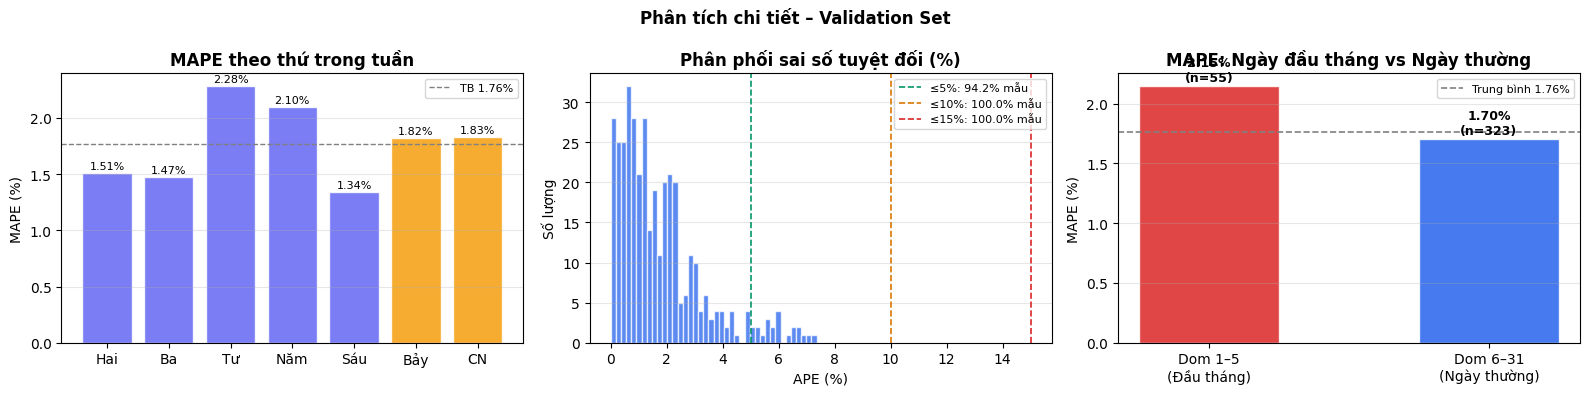

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 4b. Đánh giá chi tiết (dành cho luận văn)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("      ĐÁNH GIÁ CHI TIẾT MODEL TRÊN TẬP VALIDATION")
print("=" * 60)

# ── 1. MAPE theo từng bước dự báo (H+1 → H+7) ─────────────────────────────
print("\n[1] MAPE / MAE theo từng bước dự báo (H+1 → H+7):")
print("     Bước  │   MAE (VND)  │  MAPE (%)")
print("  " + "─" * 38)
step_mapes = []
for h in range(HORIZON):
    mae_h  = float(np.mean(np.abs(pred_vnd[:, h] - tgt_vnd[:, h])))
    mape_h = float(np.mean(np.abs(pred_vnd[:, h] - tgt_vnd[:, h]) / (tgt_vnd[:, h] + 1.0)) * 100)
    step_mapes.append(mape_h)
    print(f"     H+{h+1}    │  {mae_h:>10,.0f}  │  {mape_h:.2f}%")
drift = step_mapes[-1] - step_mapes[0]
print(f"\n  → Chênh lệch MAPE H+7 − H+1 = {drift:+.2f} pp  "
      f"({'lỗi tăng ít' if abs(drift) < 1 else 'phi-hồi quy ổn định' if drift < 0 else 'lỗi tăng nhẹ theo bước'})")

# ── 2. So sánh với Naive Baseline (lặp giá trị ngày cuối window) ───────────
print("\n[2] So sánh với Naive Baseline:")
naive_zs   = X_val[:, -1, 0]                           # last encoder step (z-score)
naive_vnd_ = denorm_vnd(naive_zs[:, None])             # (n_val, 1)
naive_pred = np.repeat(naive_vnd_, HORIZON, axis=1)    # (n_val, H)
naive_mae  = float(np.mean(np.abs(naive_pred - tgt_vnd)))
naive_mape = float(np.mean(np.abs(naive_pred - tgt_vnd) / (tgt_vnd + 1.0)) * 100)
print(f"                    Naive          Model      Cải thiện")
print(f"  MAE  (VND):  {naive_mae:>10,.0f}   {mae_vnd:>10,.0f}   ↓{(1-mae_vnd/naive_mae)*100:.1f}%")
print(f"  MAPE    (%): {naive_mape:>9.2f}%   {mape:>9.2f}%   ↓{(1-mape/naive_mape)*100:.1f}%")

# ── 3. Phân phối lỗi – tỷ lệ mẫu trong ngưỡng ─────────────────────────────
print("\n[3] Tỷ lệ dự báo nằm trong ngưỡng sai số (toàn bộ val):")
abs_pct = np.abs(pred_vnd - tgt_vnd) / (tgt_vnd + 1.0) * 100
for thr in [5, 10, 15, 20]:
    pct = float(np.mean(abs_pct <= thr) * 100)
    bar = "█" * int(pct / 4)
    print(f"  ±{thr:2d}%: {pct:5.1f}%  {bar}")

# ── 4. MAPE theo thứ trong tuần ─────────────────────────────────────────────
print("\n[4] MAPE theo thứ trong tuần:")
n_total_w   = len(df) - WINDOW - HORIZON + 1
n_val_start = n_total_w - n_val

flat_dates = []
for i in range(n_val):
    for h in range(HORIZON):
        flat_dates.append(df["date"].iloc[n_val_start + i + WINDOW + h])
flat_dates = pd.to_datetime(flat_dates)
flat_dows  = flat_dates.dayofweek.values
flat_doms  = flat_dates.day.values
flat_pred  = pred_vnd.flatten()
flat_tgt   = tgt_vnd.flatten()

dow_vn = ["Hai", "Ba ", "Tư ", "Năm", "Sáu", "Bảy", "CN "]
for d in range(7):
    mask = flat_dows == d
    if not mask.any():
        continue
    m = float(np.mean(np.abs(flat_pred[mask] - flat_tgt[mask]) / (flat_tgt[mask] + 1.0)) * 100)
    bar = "█" * int(m / 0.5)
    print(f"  Thứ {dow_vn[d]}: {m:.2f}%  {bar}")

# ── 5. MAPE: ngày đầu tháng (dom=1–5) vs ngày thường (dom=6–31) ────────────
print("\n[5] MAPE theo nhóm ngày trong tháng:")
dom1_5   = flat_doms <= 5
dom_rest = ~dom1_5
m1 = float(np.mean(np.abs(flat_pred[dom1_5]   - flat_tgt[dom1_5])   / (flat_tgt[dom1_5]   + 1.0)) * 100)
m2 = float(np.mean(np.abs(flat_pred[dom_rest] - flat_tgt[dom_rest]) / (flat_tgt[dom_rest] + 1.0)) * 100)
print(f"  Dom=1–5   (tiền nhà, hóa đơn):  MAPE={m1:.2f}%  (n={dom1_5.sum()})")
print(f"  Dom=6–31  (ngày thường)       :  MAPE={m2:.2f}%  (n={dom_rest.sum()})")
diff_dom = m1 - m2
print(f"  → Chênh lệch dom=1–5 vs dom≥6: {diff_dom:+.2f} pp  "
      f"({'đặc trưng early_month_pulse hoạt động tốt' if diff_dom < 3 else 'ngày đầu tháng khó dự báo hơn'})")

# ── 6. Tóm tắt ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"  Val MAE   = {mae_vnd:>8,.0f} VND")
print(f"  Val RMSE  = {rmse:>8,.0f} VND")
print(f"  Val MAPE  = {mape:>7.2f} %")
print(f"  Cải thiện so với Naive: MAE ↓{(1-mae_vnd/naive_mae)*100:.1f}%  |  MAPE ↓{(1-mape/naive_mape)*100:.1f}%")
print("=" * 60)

# ══════════════════════════════════════════════════════════════════════════════
# Biểu đồ chi tiết (3 charts)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Phân tích chi tiết – Validation Set", fontsize=12, fontweight="bold")

# ── [0] MAPE theo thứ trong tuần ─────────────────────────────────────────────
ax = axes[0]
dow_vn     = ["Hai", "Ba", "Tư", "Năm", "Sáu", "Bảy", "CN"]
dow_mapes  = []
dow_counts = []
for d in range(7):
    mask = flat_dows == d
    if mask.any():
        m = float(np.mean(np.abs(flat_pred[mask] - flat_tgt[mask]) / (flat_tgt[mask] + 1.0)) * 100)
    else:
        m = 0.0
    dow_mapes.append(m)
    dow_counts.append(mask.sum())
colors_dow = ["#6366f1","#6366f1","#6366f1","#6366f1","#6366f1","#f59e0b","#f59e0b"]
bars = ax.bar(dow_vn, dow_mapes, color=colors_dow, alpha=0.85, edgecolor="white")
for bar, m, n in zip(bars, dow_mapes, dow_counts):
    if m > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{m:.2f}%", ha="center", va="bottom", fontsize=8)
ax.axhline(mape, color="gray", linestyle="--", linewidth=1, label=f"TB {mape:.2f}%")
ax.set_title("MAPE theo thứ trong tuần", fontweight="bold")
ax.set_ylabel("MAPE (%)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# ── [1] Phân phối % lỗi tuyệt đối ───────────────────────────────────────────
ax = axes[1]
ax.hist(abs_pct.flatten(), bins=40, color="#2563eb", alpha=0.75, edgecolor="white")
for thr, col in [(5, "#059669"), (10, "#d97706"), (15, "#dc2626")]:
    pct_in = float(np.mean(abs_pct <= thr) * 100)
    ax.axvline(thr, color=col, linestyle="--", linewidth=1.2,
               label=f"≤{thr}%: {pct_in:.1f}% mẫu")
ax.set_title("Phân phối sai số tuyệt đối (%)", fontweight="bold")
ax.set_xlabel("APE (%)")
ax.set_ylabel("Số lượng")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# ── [2] MAPE dom=1–5 vs dom=6–31 ─────────────────────────────────────────────
ax = axes[2]
dom_groups  = ["Dom 1–5\n(Đầu tháng)", "Dom 6–31\n(Ngày thường)"]
dom_m_vals  = [m1, m2]
dom_colors  = ["#dc2626" if m1 > m2 else "#059669", "#2563eb"]
bars = ax.bar(dom_groups, dom_m_vals, color=dom_colors, alpha=0.85, width=0.5, edgecolor="white")
for bar, mv, cnt in zip(bars, dom_m_vals, [dom1_5.sum(), dom_rest.sum()]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{mv:.2f}%\n(n={cnt})", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(mape, color="gray", linestyle="--", linewidth=1.2,
           label=f"Trung bình {mape:.2f}%")
ax.set_title("MAPE: Ngày đầu tháng vs Ngày thường", fontweight="bold")
ax.set_ylabel("MAPE (%)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. Lưu model + meta
# ══════════════════════════════════════════════════════════════════════════════

meta = {
    "architecture"      : "transformer",
    "window"            : WINDOW,
    "horizon"           : HORIZON,
    "mean_log"          : mean_log,
    "median_log"        : median_log,
    "std_log"           : std_log,
    # Transformer hyperparameters
    "d_model"           : D_MODEL,
    "n_heads"           : N_HEADS,
    "n_enc_layers"      : N_ENC_LAYERS,
    "n_dec_layers"      : N_DEC_LAYERS,
    "d_ff"              : D_FF,
    "dropout"           : DROPOUT,
    "input_size"        : INPUT_SIZE,
    "n_category"        : int(N_CATEGORY),
    "mean_category"     : mean_category.tolist(),
    "use_instance_norm" : True,
    "inst_norm_recent_k": INST_NORM_K,
    "val_mae_vnd"       : int(round(mae_vnd)),
    "val_mape_pct"      : round(float(mape), 2),
}

pt_path   = MODELS / "forecast_model.pt"
meta_path = MODELS / "forecast_meta.json"

torch.save(model.state_dict(), pt_path)
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

print("Đã lưu:", pt_path)
print("Đã lưu:", meta_path)
print()
print(json.dumps(meta, indent=2, ensure_ascii=False))

Đã lưu: /content/drive/MyDrive/thesis/ai_service/models/forecast_model.pt
Đã lưu: /content/drive/MyDrive/thesis/ai_service/models/forecast_meta.json

{
  "architecture": "transformer",
  "window": 30,
  "horizon": 7,
  "mean_log": 12.30325961651134,
  "median_log": 12.292598904869262,
  "std_log": 0.36100325066782124,
  "d_model": 64,
  "n_heads": 4,
  "n_enc_layers": 3,
  "n_dec_layers": 2,
  "d_ff": 256,
  "dropout": 0.1,
  "input_size": 14,
  "n_category": 5,
  "mean_category": [
    0.3696356638763536,
    0.16424630698674755,
    0.19279590483753858,
    0.13845503163643683,
    0.13486709266292346
  ],
  "use_instance_norm": true,
  "inst_norm_recent_k": 14,
  "val_mae_vnd": 4692,
  "val_mape_pct": 1.76
}


Bundle: window=30, horizon=7

7 ngày cuối trong chuỗi (VND):
  Ngày -7:      200,268
  Ngày -6:      247,856
  Ngày -5:      144,392
  Ngày -4:      272,721
  Ngày -3:      214,747
  Ngày -2:      220,509
  Ngày -1:      171,011

Dự báo 7 ngày tới (VND):
  Ngày +1:      288,112
  Ngày +2:      263,331
  Ngày +3:      272,438
  Ngày +4:      304,486
  Ngày +5:      343,259
  Ngày +6:      323,274
  Ngày +7:      202,105


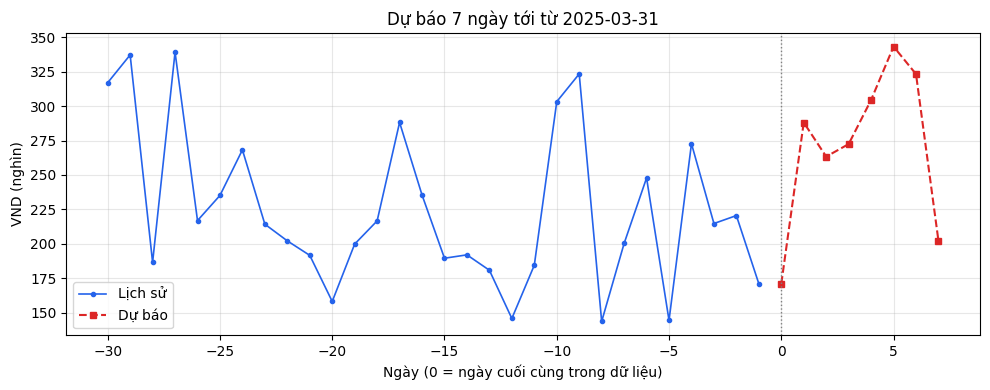

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. Kiểm tra inference end-to-end
# ══════════════════════════════════════════════════════════════════════════════

from app.forecast_infer import load_forecast_bundle, predict_horizon_vnd

bundle = load_forecast_bundle(MODELS, device=DEVICE)
assert bundle is not None, "Bundle không tải được!"
print(f"Bundle: window={bundle.window}, horizon={bundle.horizon}")

# Dự báo từ 30 ngày cuối trong dataset
tail          = series_raw[-WINDOW:].tolist()
last_date_str = str(df["date"].iloc[-1].date())

preds = predict_horizon_vnd(bundle, tail, last_date=last_date_str)

print(f"\n7 ngày cuối trong chuỗi (VND):")
for i, v in enumerate(tail[-7:], 1):
    print(f"  Ngày -{7-i+1}: {int(v):>12,.0f}")

print(f"\nDự báo {HORIZON} ngày tới (VND):")
for i, v in enumerate(preds, 1):
    print(f"  Ngày +{i}: {v:>12,}")

# ── Biểu đồ so sánh ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
hist_days  = list(range(-WINDOW, 0))
future_days = list(range(1, HORIZON + 1))

ax.plot(hist_days, [v / 1000 for v in tail], "o-",
        color="#2563eb", linewidth=1.2, markersize=3, label="Lịch sử")
ax.plot([0] + future_days, [tail[-1] / 1000] + [v / 1000 for v in preds],
        "s--", color="#dc2626", linewidth=1.5, markersize=5, label="Dự báo")
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Ngày (0 = ngày cuối cùng trong dữ liệu)")
ax.set_ylabel("VND (nghìn)")
ax.set_title(f"Dự báo {HORIZON} ngày tới từ {last_date_str}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()